# 08 — Results Visualisation

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 2.1
Updated 2026-07-15 (RQ1 reporting freeze): Figure 08b now consumes the validated five-test BH-FDR, 95% mean-CAR intervals and Cohen's d table from Notebook 04. Figures 08c/08d retain the validated 92-feature FES v1.1 results and use XGBoost only as a non-constant diagnostic view—not as a winner. Figure hashes and upstream bindings are persisted in `reports/figures/results_visualisation_validation.json`.

---

## Purpose

Produce integrated, publication-style figures narrating the full pipeline for the dissertation, sourced exclusively from the frozen canonical artefacts.

1. **Figure 08a — Event Landscape** — event volume, type distribution, sentiment over time, president breakdown
2. **Figure 08b — Causal Evidence** — CAR distributions, BH-FDR/effect sizes, DoWhy estimates with CI, sentiment-CAR scatter, regime interaction
3. **Figure 08c — Predictive Pipeline** — FES v1.1 RF importance, 4-model comparison, diagnostic-model SHAP, RQ2/RQ3 verdicts
4. **Figure 08d — Full-Period Dashboard** — integrated test-period timeline: SPY + VIX + events + non-constant diagnostic signal + illustrative cumulative return

## Inputs

- `data/processed/{events_tagged, daily_sentiment, car_results, event_type_statistics, causal_estimates, feature_matrix}.parquet`
- `reports/model_comparison/{model_comparison, feature_importance, event_model_predictions, shap_values_event_lasso, shap_values_xgboost, shap_values_lightgbm, statistical_tests.json}`
- `reports/baseline/baseline_predictions.parquet`

No legacy artefact (`model_features.parquet`, `feature_metadata.parquet`, `test_predictions.parquet`, `shap_values.parquet`, `model_comparison.parquet` in `data/processed/`, `evaluation_summary.parquet`, `models/model_metadata.json`) is read anywhere in this notebook.

## Outputs

`reports/figures/08a_event_landscape.png` … `08d_full_dashboard.png` (300 dpi).

## Research Questions Supported

RQ1 (`08a`, `08b`), RQ2 (`08c` — feature importance/SHAP), RQ3 (`08c`, `08d` — 4-model comparison and RQ3 verdict, explicitly stating H0(3) not rejected).

## Pipeline Position

`07_model_evaluation.ipynb` → **`08_results_visualisation.ipynb`** → Dissertation.

## Scope — this notebook DOES

- Assemble multi-panel dissertation figures from already-computed, frozen upstream outputs
- State the RQ3 verdict (H0(3) not rejected) explicitly on every figure/panel that compares models, so no figure can be read as claiming a model "wins"

## Scope — this notebook does NOT

- Perform any new analysis, statistical test, or model training
- Change any model conclusion, frozen dataset, or model artefact
- Claim any event-enhanced model beats `Baseline_LASSO` — none does, at the Bonferroni-corrected threshold

**Inputs:** see above
**Outputs:** `08a`–`08d` PNG figures (300 dpi, dissertation-ready)

In [1]:
import os, sys, warnings, pickle, json, hashlib
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from matplotlib.patches import Patch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT   = Path('..').resolve()
PROC   = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
FIGS   = ROOT / 'reports' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

# ── Publication plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':          150,
    'savefig.dpi':         300,       # dissertation quality
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.grid':           True,
    'grid.alpha':          0.25,
    'grid.linestyle':      '--',
    'font.family':         'sans-serif',
    'font.size':           10,
    'axes.titlesize':      11,
    'axes.labelsize':      10,
    'legend.fontsize':     8,
    'xtick.labelsize':     8,
    'ytick.labelsize':     8,
})

# ── Colour palette (consistent across all figures) ────────────────────────────
C = {
    'monetary':    '#1f4e79',
    'geopolitical':'#c55a11',
    'regulatory':  '#70ad47',
    'trade':       '#7030a0',
    'energy':      '#d4a017',
    'other':       '#95a5a6',
    'positive':    '#27ae60',
    'negative':    '#e74c3c',
    'neutral':     '#95a5a6',
    'spy':         '#2c3e50',
    'vix':         '#e74c3c',
    'lasso':       '#1f4e79',
    'xgb':         '#c55a11',
    'lgb':         '#70ad47',
    'strategy':    '#7030a0',
    'bh':          '#95a5a6',
}

EVENT_ORDER = ['monetary','geopolitical','regulatory','trade','energy']

print('✓ Imports complete — publication style active')

✓ Imports complete — publication style active


---
## Section 1 — Load All Data

In [2]:
# ── Phase 3 outputs (current, unchanged) ───────────────────────────────────────
events_df   = pd.read_parquet(PROC / 'events_tagged.parquet')
sent_df     = pd.read_parquet(PROC / 'daily_sentiment.parquet')
events_df['date'] = pd.to_datetime(events_df['date'])
sent_df['date']   = pd.to_datetime(sent_df['date'])

# ── Phase 4 outputs (current, unchanged) ───────────────────────────────────────
car_df     = pd.read_parquet(PROC / 'car_results.parquet')
rq1_stats  = pd.read_parquet(PROC / 'event_type_statistics.parquet')
causal_df  = pd.read_parquet(PROC / 'causal_estimates.parquet')
car_df['date'] = pd.to_datetime(car_df['date'])

# ── Canonical feature/model pipeline (FES v1.1 / MCP v1.0) ─────────────────────
# Migrated 2026-07-14 after Notebook 07 validation PASS. Replaces the
# legacy model_features.parquet / feature_metadata.parquet / test_predictions.parquet /
# shap_values.parquet / model_comparison.parquet / evaluation_summary.parquet /
# models/model_metadata.json previously read here -- see 10_decision_log.md.
MC   = ROOT / 'reports' / 'model_comparison'
BASE = ROOT / 'reports' / 'baseline'

feat_df = pd.read_parquet(PROC / 'feature_matrix.parquet')   # FES v1.1 -- 92 features, 2,477 rows
feat_df['date'] = pd.to_datetime(feat_df['date'])

comp_df            = pd.read_parquet(MC / 'model_comparison.parquet')          # Baseline_LASSO/Event_LASSO/XGBoost/LightGBM x train/test
feat_imp_df        = pd.read_parquet(MC / 'feature_importance.parquet')        # 92 features x importance/category
event_preds_df     = pd.read_parquet(MC / 'event_model_predictions.parquet')   # date, split, actual, {model}_pred
baseline_preds_df  = pd.read_parquet(BASE / 'baseline_predictions.parquet')
event_preds_df['date']    = pd.to_datetime(event_preds_df['date'])
baseline_preds_df['date'] = pd.to_datetime(baseline_preds_df['date'])

shap_dfs = {
    'Event_LASSO': pd.read_parquet(MC / 'shap_values_event_lasso.parquet'),
    'XGBoost':     pd.read_parquet(MC / 'shap_values_xgboost.parquet'),
    'LightGBM':    pd.read_parquet(MC / 'shap_values_lightgbm.parquet'),
}

with open(MC / 'statistical_tests.json') as f:
    stats_tests = json.load(f)

with open(PROC / 'feature_matrix_validation.json') as f:
    feature_validation = json.load(f)
with open(BASE / 'baseline_model_validation.json') as f:
    baseline_validation = json.load(f)
with open(MC / 'model_evaluation_validation.json') as f:
    model_eval_validation = json.load(f)

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as fh:
        for block in iter(lambda: fh.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

matrix_hash = sha256(PROC / 'feature_matrix.parquet')
assert feature_validation['validation_status'] == 'PASS'
assert feature_validation['fes_version'] == '1.1'
assert feature_validation['feature_count'] == 92
assert baseline_validation['validation_status'] == 'PASS'
assert baseline_validation['feature_matrix_sha256'] == matrix_hash
assert model_eval_validation['validation_status'] == 'PASS'
assert model_eval_validation['feature_matrix_sha256'] == matrix_hash
assert model_eval_validation['feature_count'] == 92
assert stats_tests['feature_matrix_sha256'] == matrix_hash
assert stats_tests['rq3_verdict'] == 'H0(3) NOT REJECTED'
assert len(feat_imp_df) == 92 and np.isclose(feat_imp_df['importance'].sum(), 1.0)

# Train/test split boundary under FES v1.1 (see feature_profile.json)
TRAIN_CUT = feat_df[feat_df['split'] == 'train']['date'].max()

# Diagnostic model for panels that require prediction variation. Event_LASSO is
# exactly baseline-equivalent and constant under FES v1.1, so it cannot support
# meaningful scatter/rolling-IC panels. Select the non-constant event candidate
# with the highest defined held-out IC; this is a visual diagnostic, never a winner.
test_metrics = comp_df[comp_df['Split'] == 'test'].set_index('Model')
diagnostic_candidates = [m for m in ['XGBoost', 'LightGBM']
                         if pd.notna(test_metrics.loc[m, 'IC'])
                         and event_preds_df[f'{m}_pred'].nunique() > 1]
REPRESENTATIVE_MODEL = max(diagnostic_candidates, key=lambda m: test_metrics.loc[m, 'IC'])

test_preds = event_preds_df[event_preds_df['split'] == 'test'].sort_values('date').reset_index(drop=True)
y_true     = test_preds['actual'].values
y_rep      = test_preds[f'{REPRESENTATIVE_MODEL}_pred'].values
rep_dates  = test_preds['date'].values

assert set(rq1_stats['event_type']) == set(EVENT_ORDER)
assert not rq1_stats['reject_bh_0_05'].any()
assert rq1_stats['p_value_bh'].min() >= 0.05
rq1_event_type_p = rq1_stats.set_index('event_type')['p_value_raw'].to_dict()
# \u2500\u2500 Pooled/overall DoWhy estimate: read from its dedicated artefact \u2500\u2500\u2500\u2500\u2500\u2500
# Previously a hand-copied literal with no persisted source file. causal_df
# above (causal_estimates.parquet) holds only the five per-event-type rows --
# a different estimand -- so the pooled figure is read from
# causal_overall_estimate.json instead, written by Notebook 04 (see
# 10_decision_log.md, 2026-07-15 correction entry).
overall_estimate_path = PROC / 'causal_overall_estimate.json'
with open(overall_estimate_path) as f:
    _overall = json.load(f)

if isinstance(_overall, list):
    raise ValueError('causal_overall_estimate.json must contain exactly one pooled estimate, found a list')

_REQUIRED_OVERALL_FIELDS = {'causal_effect', 'ci_lower', 'ci_upper', 'p_value', 'n_obs'}
_missing_overall_fields = _REQUIRED_OVERALL_FIELDS - set(_overall.keys())
assert not _missing_overall_fields, f'causal_overall_estimate.json missing required fields: {sorted(_missing_overall_fields)}'
assert np.isfinite(_overall['causal_effect']), 'causal_effect is not finite'
assert np.isfinite(_overall['ci_lower']) and np.isfinite(_overall['ci_upper']), 'a CI bound is not finite'
assert _overall['ci_lower'] <= _overall['causal_effect'] <= _overall['ci_upper'], (
    'causal_effect falls outside its own confidence interval'
)
assert _overall.get('n_obs', 0) > 0, 'n_obs must be positive'

rq1_overall_dowhy = {
    'effect': _overall['causal_effect'],
    'ci_lower': _overall['ci_lower'],
    'ci_upper': _overall['ci_upper'],
    'p_value': _overall['p_value'],
}
rq3_verdict = stats_tests['rq3_verdict']
rq2_rf = model_eval_validation['random_forest_rq2']
rq2_verdict = 'H0 NOT REJECTED' if (not rq2_rf['top_decile_contains_event'] and rq2_rf['top_decile_contains_macro']) else 'REVIEW'
assert len(test_preds) == model_eval_validation['test_rows'] == 750
assert feat_df['split'].value_counts().to_dict() == {'train': 1727, 'test': 750}

print(f'Events           : {len(events_df):,}')
print(f'CAR records      : {len(car_df):,}')
print(f'Feature matrix   : {feat_df.shape[0]:,} rows x {feat_df.shape[1]} cols (FES v1.1; 92 features)')
print(f'Test days        : {len(test_preds):,}')
print(f'Non-constant diagnostic model (not a winner): {REPRESENTATIVE_MODEL}')
print(f'RQ1 event-type minimum p-value: {min(rq1_event_type_p.values()):.3f} (null)')
print(f'RQ1 BH-FDR minimum q-value: {rq1_stats["p_value_bh"].min():.3f}; rejections=0/5')
print(f'RQ2 verdict (frozen RF rule): {rq2_verdict}')
print(f'RQ3 verdict (all 3 event-enhanced models): {rq3_verdict}')
print('✓ All canonical data loaded -- no legacy pipeline files read')

Events           : 1,005
CAR records      : 264
Feature matrix   : 2,477 rows x 95 cols (FES v1.1; 92 features)
Test days        : 750
Non-constant diagnostic model (not a winner): XGBoost
RQ1 event-type minimum p-value: 0.116 (null)
RQ1 BH-FDR minimum q-value: 0.581; rejections=0/5
RQ2 verdict (frozen RF rule): H0 NOT REJECTED
RQ3 verdict (all 3 event-enhanced models): H0(3) NOT REJECTED
✓ All canonical data loaded -- no legacy pipeline files read


---
## Figure 08a — Event Landscape (2015–2025)

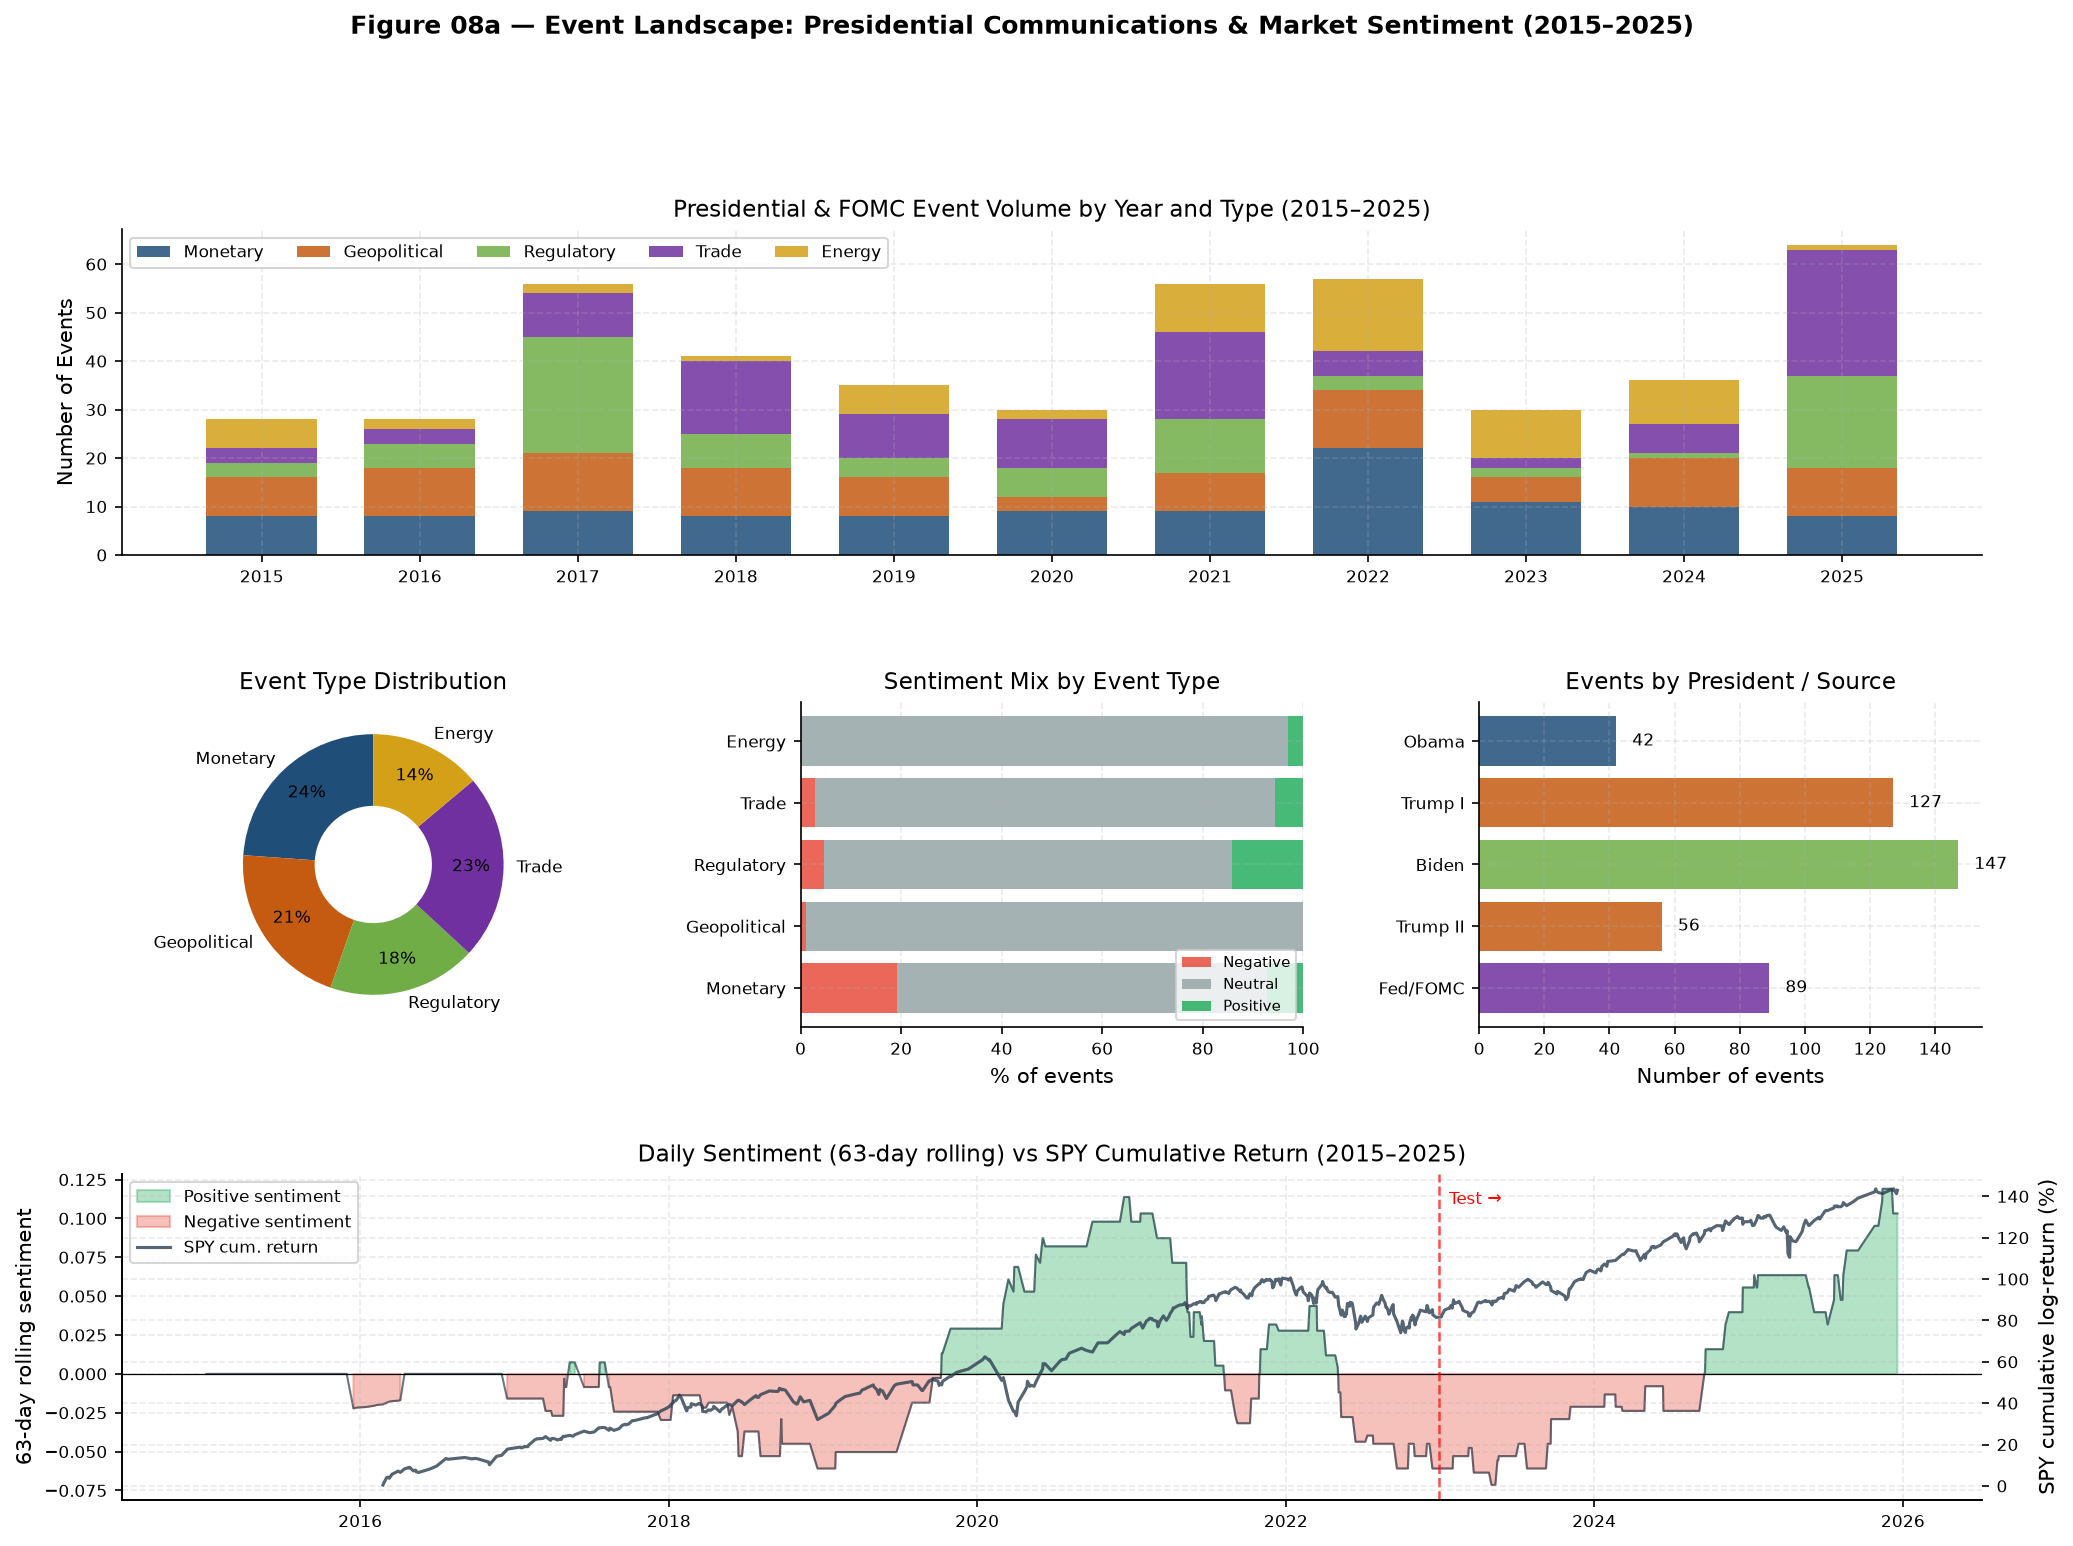

✓ Saved 08a_event_landscape.png


In [3]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1 (top, full width): Event volume over time by type ─────────────────
ax1 = fig.add_subplot(gs[0, :])
yearly = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .assign(year=events_df['date'].dt.year)
    .groupby(['year','event_type'])
    .size().unstack(fill_value=0)
)
# Reorder columns
yearly = yearly.reindex(columns=[e for e in EVENT_ORDER if e in yearly.columns])
bottom = np.zeros(len(yearly))
for col in yearly.columns:
    ax1.bar(yearly.index, yearly[col], bottom=bottom,
            color=C[col], alpha=0.85, label=col.capitalize(), width=0.7)
    bottom += yearly[col].values
ax1.set_ylabel('Number of Events')
ax1.set_title('Presidential & FOMC Event Volume by Year and Type (2015–2025)')
ax1.legend(loc='upper left', ncol=5, fontsize=8)
ax1.set_xticks(yearly.index)

# ── Panel 2 (mid-left): Event type distribution (donut) ──────────────────────
ax2 = fig.add_subplot(gs[1, 0])
type_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['event_type'].value_counts().reindex(EVENT_ORDER).fillna(0)
)
wedges, texts, autotexts = ax2.pie(
    type_counts.values,
    labels=[t.capitalize() for t in type_counts.index],
    colors=[C[t] for t in type_counts.index],
    autopct='%1.0f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55)
)
for at in autotexts: at.set_fontsize(8)
ax2.set_title('Event Type Distribution')

# ── Panel 3 (mid-centre): Sentiment distribution by event type ───────────────
ax3 = fig.add_subplot(gs[1, 1])
sent_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .groupby(['event_type','sentiment_label'])
    .size().unstack(fill_value=0)
)
sent_counts = sent_counts.reindex(index=EVENT_ORDER)
sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0) * 100
bottom_s = np.zeros(len(sent_pct))
for sent_label, col in [('negative', C['negative']), ('neutral', C['neutral']), ('positive', C['positive'])]:
    if sent_label in sent_pct.columns:
        ax3.barh([e.capitalize() for e in sent_pct.index],
                 sent_pct[sent_label], left=bottom_s,
                 color=col, alpha=0.85, label=sent_label.capitalize())
        bottom_s += sent_pct[sent_label].values
ax3.set_xlabel('% of events')
ax3.set_title('Sentiment Mix by Event Type')
ax3.legend(loc='lower right', fontsize=7)
ax3.set_xlim(0, 100)

# ── Panel 4 (mid-right): Events by president ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
pres_short = {
    'Barack Obama':              'Obama',
    'Donald J. Trump (1st Term)':'Trump I',
    'Joseph R. Biden, Jr.':      'Biden',
    'Donald J. Trump (2nd Term)':'Trump II',
    'Federal Reserve':           'Fed/FOMC',
}
pres_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['president'].map(pres_short).value_counts()
)
pres_order = ['Obama','Trump I','Biden','Trump II','Fed/FOMC']
pres_counts = pres_counts.reindex([p for p in pres_order if p in pres_counts.index])
PALETTE_PRES = ['#1f4e79','#c55a11','#70ad47','#c55a11','#7030a0']
ax4.barh(pres_counts.index[::-1], pres_counts.values[::-1],
         color=PALETTE_PRES[:len(pres_counts)][::-1],
         alpha=0.85)
for i, val in enumerate(pres_counts.values[::-1]):
    ax4.text(val + 5, i, str(val), va='center', fontsize=8)
ax4.set_xlabel('Number of events')
ax4.set_title('Events by President / Source')

# ── Panel 5 (bottom, full width): Rolling daily sentiment vs SPY ─────────────
ax5 = fig.add_subplot(gs[2, :])
daily_overall = sent_df.set_index('date')['overall_mean_sentiment'].fillna(0)
rolling_sent  = daily_overall.rolling(63, min_periods=1).mean()
# SPY log-returns cumulative
spy_ret = feat_df.set_index('date')['log_return']
spy_cum = (spy_ret.cumsum() * 100).reindex(rolling_sent.index, method='ffill')

ax5b = ax5.twinx()
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent >= 0, alpha=0.35, color=C['positive'], label='Positive sentiment')
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent < 0, alpha=0.35, color=C['negative'], label='Negative sentiment')
ax5.plot(rolling_sent.index, rolling_sent, linewidth=1, color='#2c3e50', alpha=0.7)
ax5b.plot(spy_cum.index, spy_cum.values, color=C['spy'], linewidth=1.5, alpha=0.8, label='SPY cum. return')
ax5.set_ylabel('63-day rolling sentiment')
ax5b.set_ylabel('SPY cumulative log-return (%)')
ax5.set_title('Daily Sentiment (63-day rolling) vs SPY Cumulative Return (2015–2025)')
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax5.axhline(0, color='black', linewidth=0.6)
# Mark train/test split
ax5.axvline(pd.Timestamp(TRAIN_CUT), color='red', linewidth=1.2,
            linestyle='--', alpha=0.7, label='Train/test split')
ax5.text(pd.Timestamp(TRAIN_CUT), ax5.get_ylim()[1] * 0.85, '  Test →',
         color='red', fontsize=8)

plt.suptitle('Figure 08a — Event Landscape: Presidential Communications & Market Sentiment (2015–2025)',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig(FIGS / '08a_event_landscape.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08a_event_landscape.png')

---
## Figure 08b — Causal Evidence

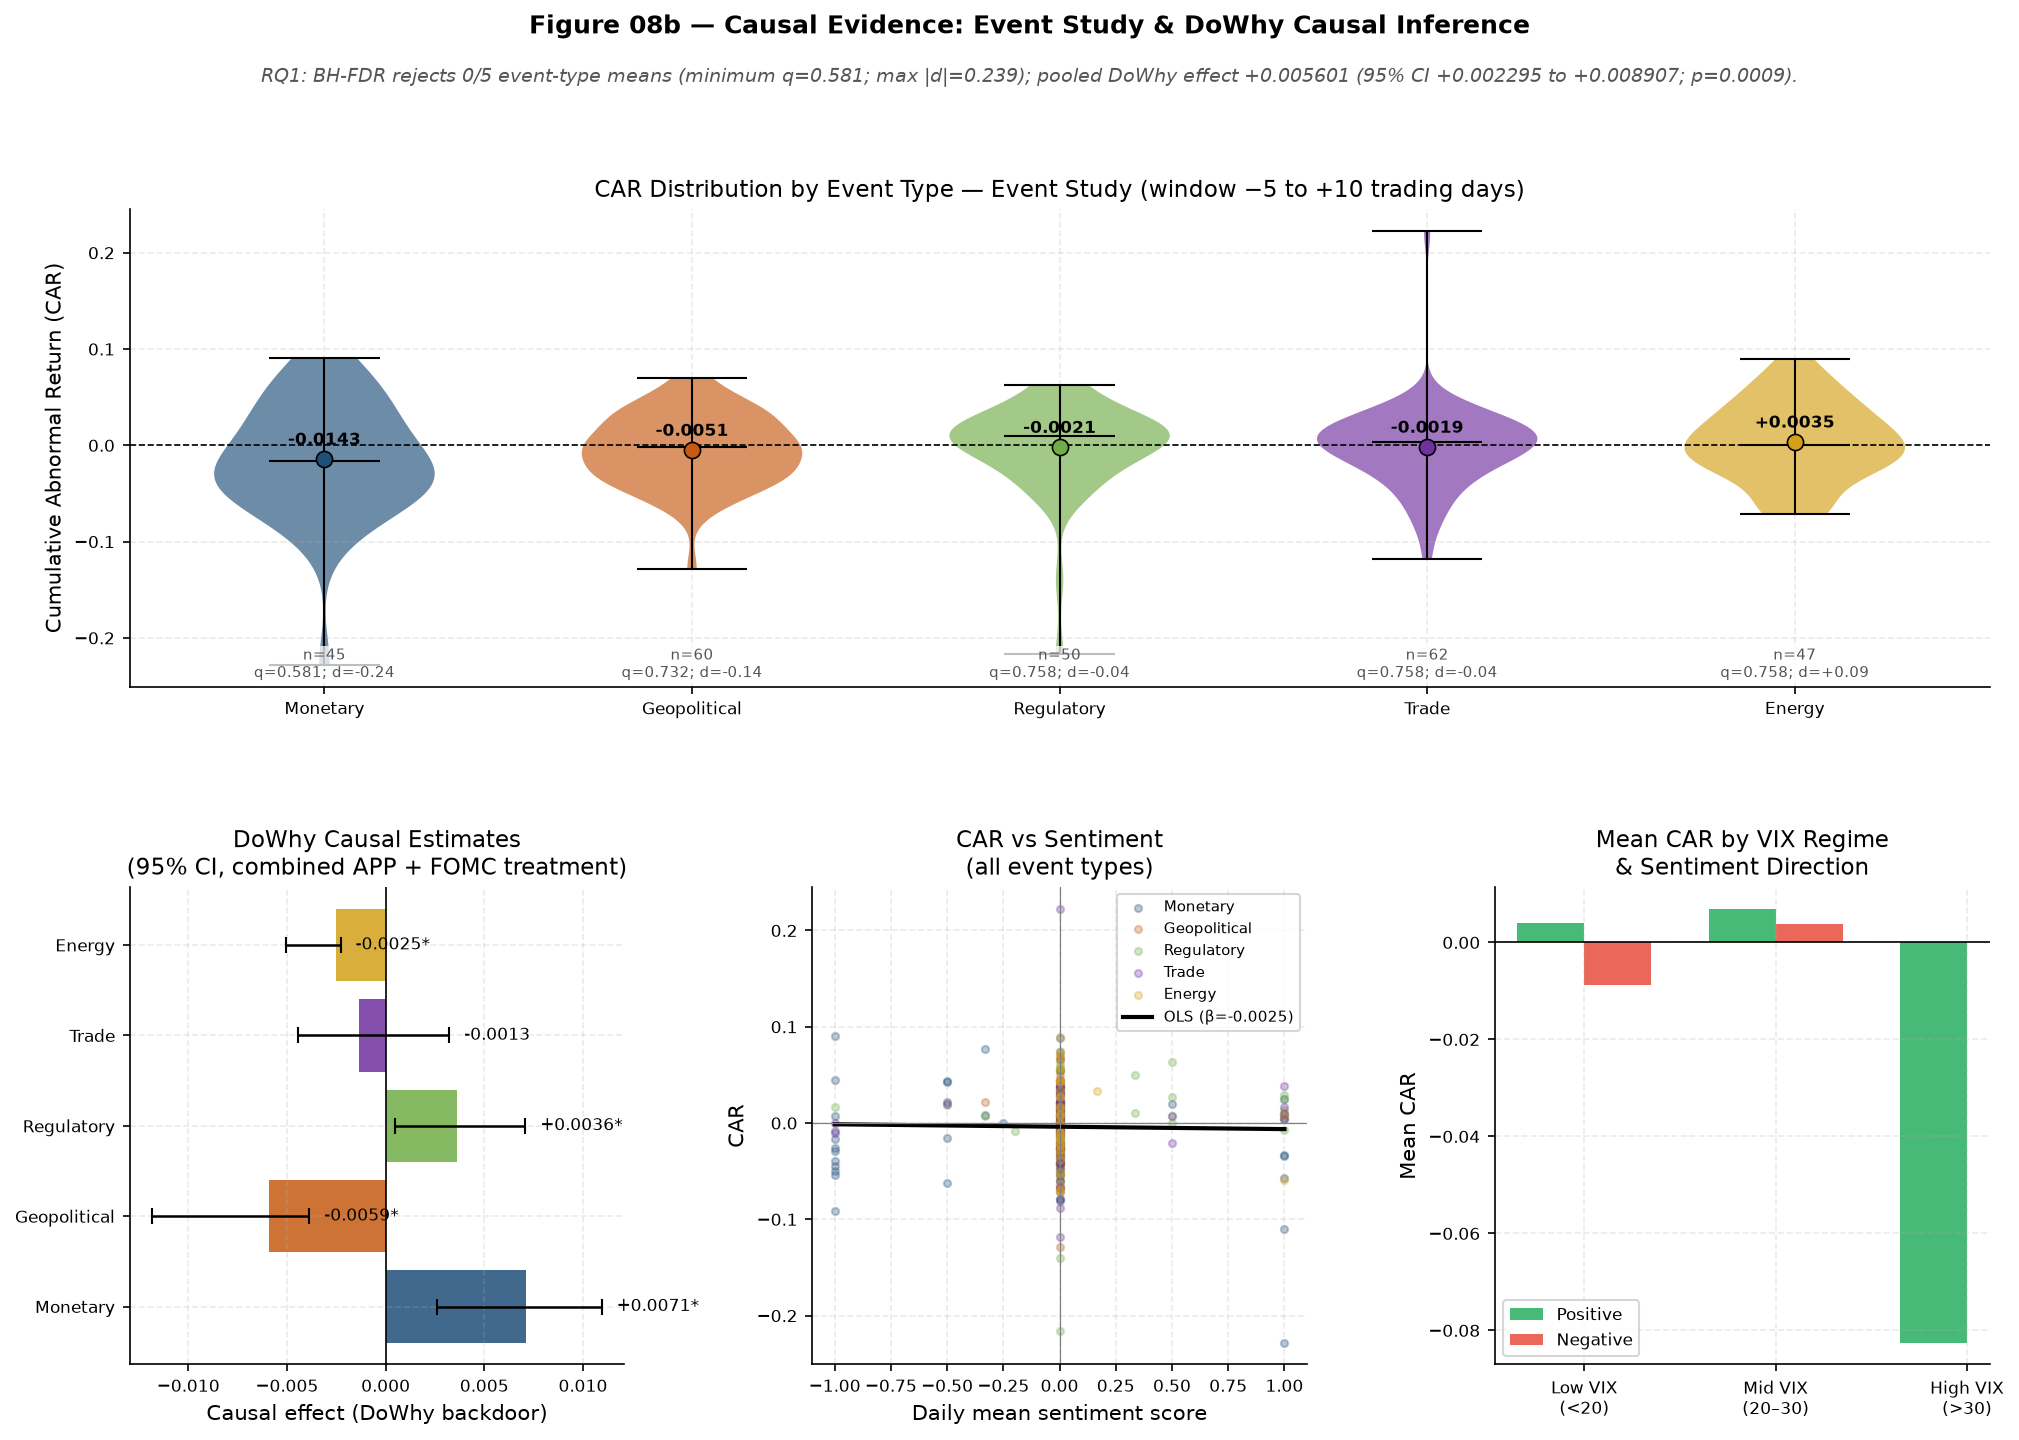

✓ Saved 08b_causal_evidence.png


In [4]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Panel 1: CAR distribution by event type (violin) ─────────────────────────
ax1 = fig.add_subplot(gs[0, :])
car_plot = car_df[car_df['event_type'].isin(EVENT_ORDER)].copy()
car_plot['event_type_label'] = car_plot['event_type'].str.capitalize()
order_labels = [e.capitalize() for e in EVENT_ORDER]

vp = ax1.violinplot(
    [car_plot[car_plot['event_type'] == et]['car'].dropna().values for et in EVENT_ORDER],
    positions=range(len(EVENT_ORDER)),
    showmedians=True, showextrema=True, widths=0.6
)
for pc, et in zip(vp['bodies'], EVENT_ORDER):
    pc.set_facecolor(C[et])
    pc.set_alpha(0.65)
for part in ['cmedians','cmaxes','cmins','cbars']:
    vp[part].set_color('black')
    vp[part].set_linewidth(1)

# Mean CAR dots
for i, et in enumerate(EVENT_ORDER):
    grp = car_plot[car_plot['event_type'] == et]['car'].dropna()
    mean_car = grp.mean()
    ax1.scatter(i, mean_car, s=60, color=C[et], zorder=5, edgecolors='black', linewidths=0.8)
    ax1.text(i, mean_car + 0.015, f'{mean_car:+.4f}', ha='center', fontsize=8, fontweight='bold')

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xticks(range(len(EVENT_ORDER)))
ax1.set_xticklabels(order_labels)
ax1.set_ylabel('Cumulative Abnormal Return (CAR)')
ax1.set_title('CAR Distribution by Event Type — Event Study (window −5 to +10 trading days)')

# Event-type sample size, BH-FDR q-value and standardised effect size
rq1_display = rq1_stats.set_index('event_type')
for i, et in enumerate(EVENT_ORDER):
    row = rq1_display.loc[et]
    ax1.text(i, ax1.get_ylim()[0] + 0.01,
             f'n={int(row["n"])}\nq={row["p_value_bh"]:.3f}; d={row["cohens_d"]:+.2f}',
             ha='center', fontsize=7, color='#555555',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5))

# ── Panel 2: DoWhy causal estimates with CI ───────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
# The persisted `sentiment_method == 'lexicon'` value is a legacy field label.
# In the current pipeline these estimates use the combined same-day APP + FOMC
# sentiment treatment documented by Notebook 04, not a lexicon score.
current_est = causal_df[causal_df['sentiment_method'] == 'lexicon'].copy()
current_est = current_est.set_index('event_type').reindex(EVENT_ORDER).dropna(subset=['causal_effect'])
y_pos = range(len(current_est))
ax2.barh(y_pos, current_est['causal_effect'].values,
         xerr=[
             current_est['causal_effect'].values - current_est['ci_lower'].values,
             current_est['ci_upper'].values - current_est['causal_effect'].values,
         ],
         color=[C[et] for et in current_est.index],
         alpha=0.85, capsize=4, error_kw=dict(linewidth=1.2))
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([e.capitalize() for e in current_est.index])
ax2.set_xlabel('Causal effect (DoWhy backdoor)')
ax2.set_title('DoWhy Causal Estimates\n(95% CI, combined APP + FOMC treatment)')
for i, (et, row) in enumerate(current_est.iterrows()):
    sig_marker = '*' if row['ci_lower'] > 0 or row['ci_upper'] < 0 else ''
    ax2.text(row['ci_upper'] + 0.0005, i, f" {row['causal_effect']:+.4f}{sig_marker}",
             va='center', fontsize=8)

# ── Panel 3: CAR vs sentiment scatter ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
for et in EVENT_ORDER:
    grp = car_df[car_df['event_type'] == et].dropna(subset=['car','overall_mean_sentiment'])
    if len(grp) < 5:
        continue
    ax3.scatter(grp['overall_mean_sentiment'], grp['car'],
                alpha=0.3, s=12, color=C[et], label=et.capitalize())
# OLS line on all events
all_grp = car_df.dropna(subset=['car','overall_mean_sentiment'])
m, b    = np.polyfit(all_grp['overall_mean_sentiment'], all_grp['car'], 1)
x_range = np.linspace(all_grp['overall_mean_sentiment'].min(),
                      all_grp['overall_mean_sentiment'].max(), 100)
ax3.plot(x_range, m * x_range + b, 'k-', linewidth=2, label=f'OLS (β={m:.4f})')
ax3.axhline(0, color='grey', linewidth=0.6)
ax3.axvline(0, color='grey', linewidth=0.6)
ax3.set_xlabel('Daily mean sentiment score')
ax3.set_ylabel('CAR')
ax3.set_title('CAR vs Sentiment\n(all event types)')
ax3.legend(fontsize=7)

# ── Panel 4: CAR by VIX regime & sentiment direction ─────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
car_df['vix_regime_label'] = pd.cut(
    car_df['vix'],
    bins=[0, 20, 30, 100],
    labels=['Low VIX\n(<20)', 'Mid VIX\n(20–30)', 'High VIX\n(>30)']
)
car_df['sent_direction'] = car_df['sentiment_numeric'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)
regime_sent = (
    car_df[car_df['sent_direction'].isin(['Positive','Negative'])]
    .groupby(['vix_regime_label','sent_direction'])['car']
    .mean().unstack()
)
if not regime_sent.empty:
    x_pos = np.arange(len(regime_sent))
    w = 0.35
    for j, (col, clr) in enumerate([('Positive', C['positive']), ('Negative', C['negative'])]):
        if col in regime_sent.columns:
            bars = ax4.bar(x_pos + j * w, regime_sent[col], w,
                           color=clr, alpha=0.85, label=col)
    ax4.set_xticks(x_pos + w/2)
    ax4.set_xticklabels(regime_sent.index)
    ax4.axhline(0, color='black', linewidth=0.8)
    ax4.set_ylabel('Mean CAR')
    ax4.set_title('Mean CAR by VIX Regime\n& Sentiment Direction')
    ax4.legend(fontsize=8)

plt.suptitle('Figure 08b — Causal Evidence: Event Study & DoWhy Causal Inference',
             fontsize=12, fontweight='bold', y=1.01)
fig.text(0.5, 0.965,
         'RQ1: BH-FDR rejects 0/5 event-type means (minimum q=0.581; max |d|=0.239); pooled DoWhy effect '
         '+0.005601 (95% CI +0.002295 to +0.008907; p=0.0009).',
         ha='center', fontsize=9, style='italic', color='#555555')
plt.savefig(FIGS / '08b_causal_evidence.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08b_causal_evidence.png')

---
## Figure 08c — Predictive Pipeline

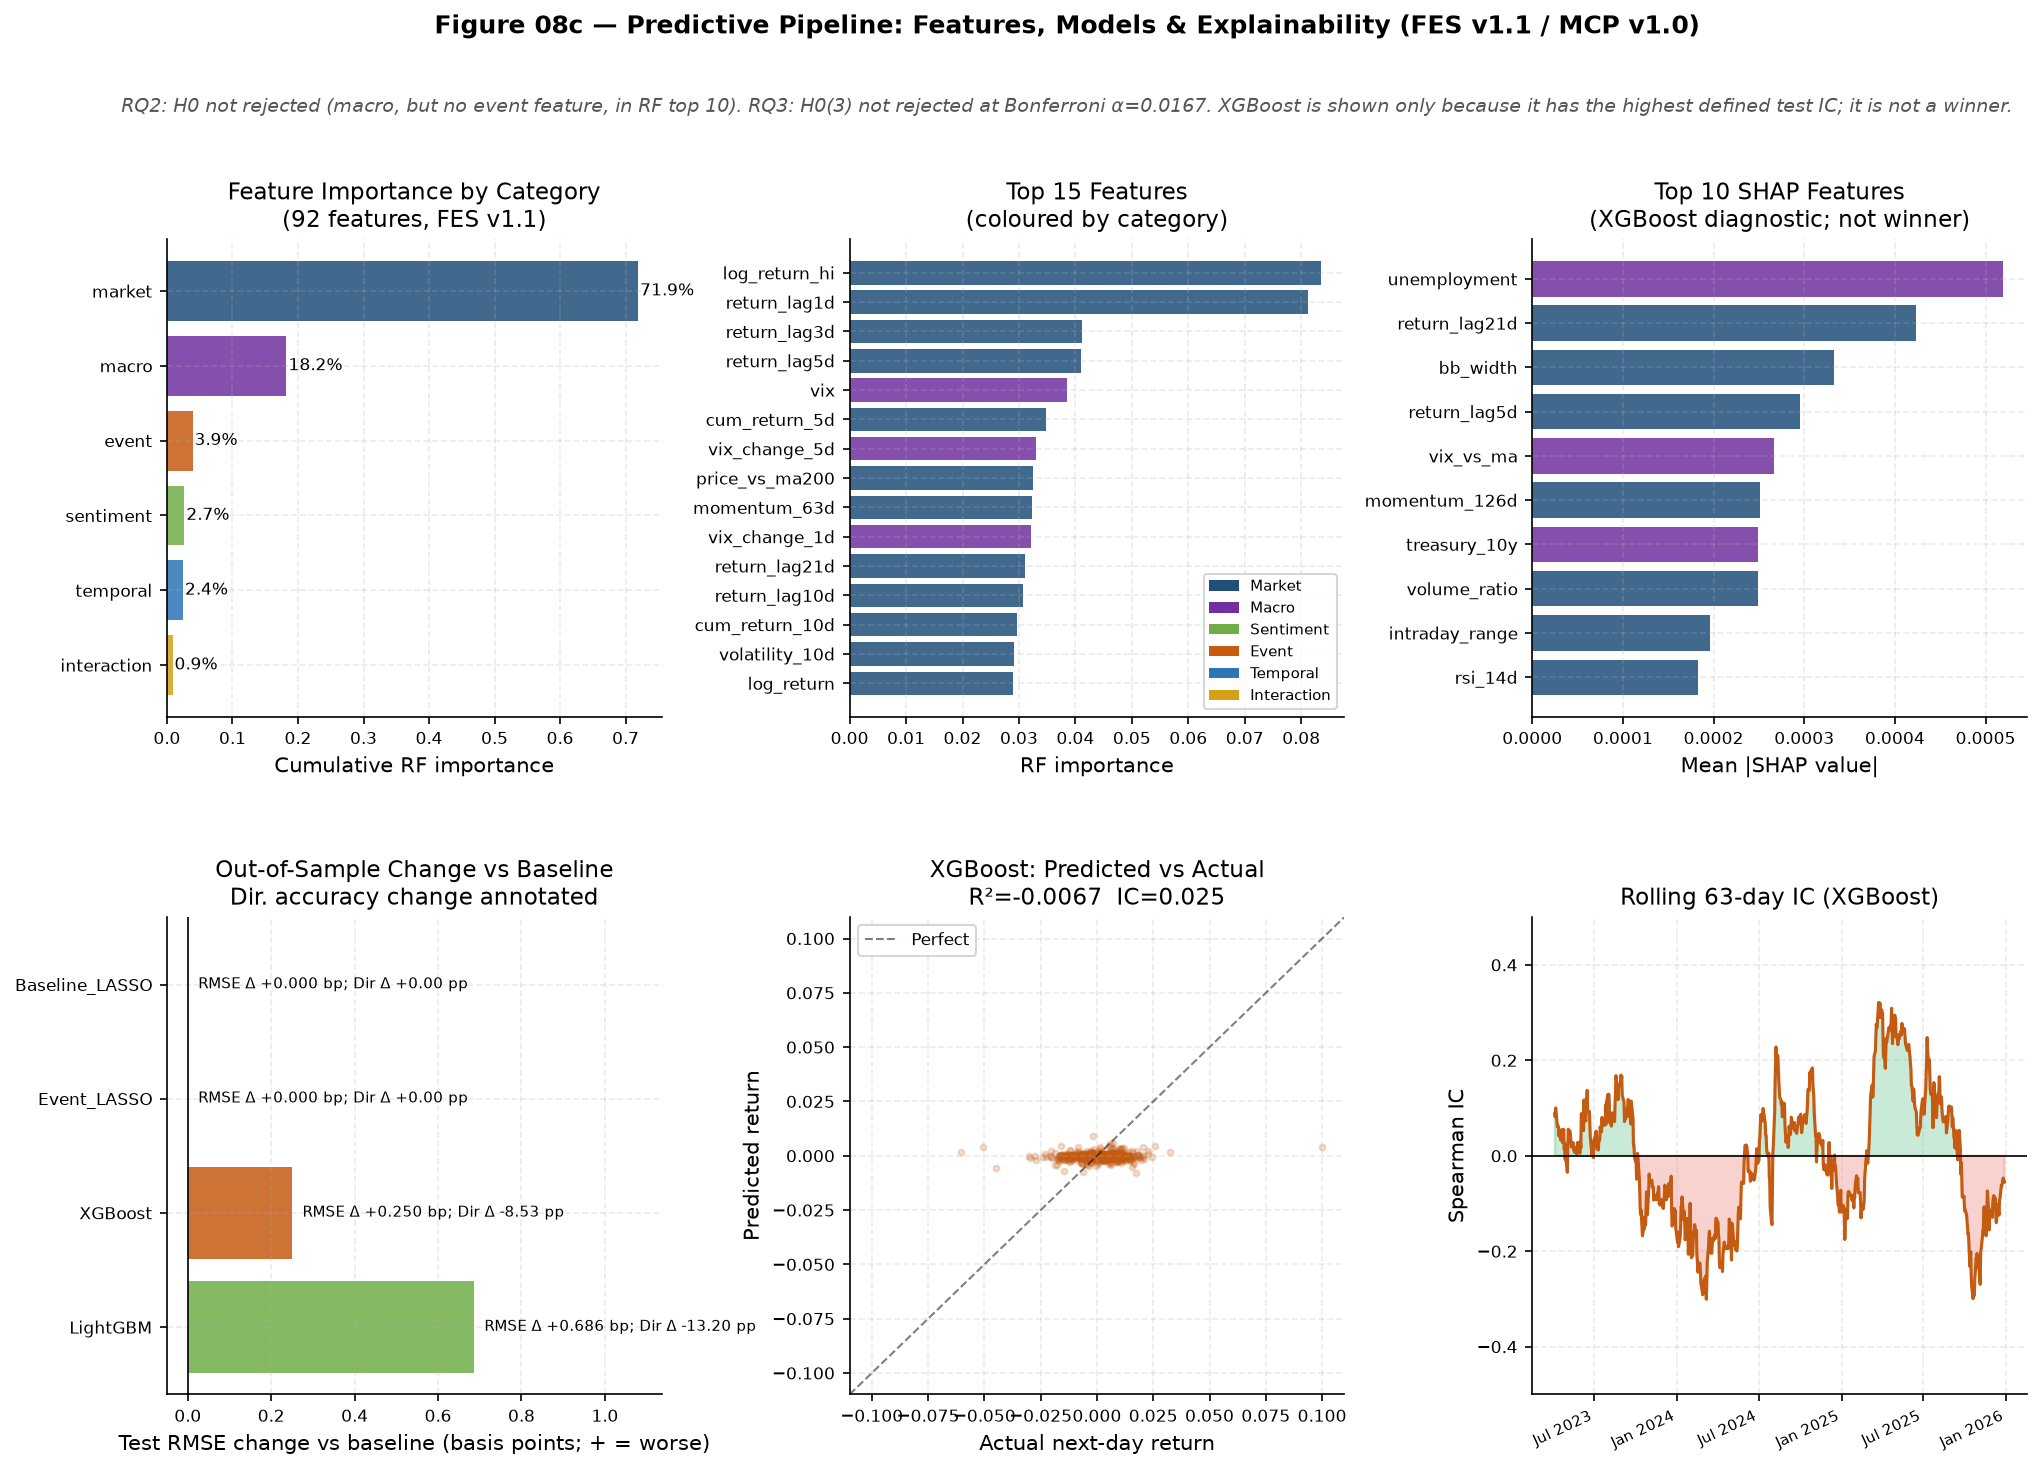

✓ Saved 08c_predictive_pipeline.png (FES v1.1 / MCP v1.0; no legacy inputs)


In [5]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

CATEGORY_COLOURS = {
    'market':      '#1f4e79',
    'macro':       '#7030a0',
    'sentiment':   '#70ad47',
    'event':       '#c55a11',
    'temporal':    '#2e75b6',
    'interaction': '#d4a017',
}
MODEL_COLOURS = {'Baseline_LASSO': '#95a5a6', 'Event_LASSO': C['lasso'], 'XGBoost': C['xgb'], 'LightGBM': C['lgb']}

# ── Panel 1: Feature importance by category (all 92 FES v1.1 features) ───────
ax1 = fig.add_subplot(gs[0, 0])
cat_imp = feat_imp_df.groupby('category')['importance'].sum().sort_values(ascending=False)
bar_colours = [CATEGORY_COLOURS.get(c, '#888') for c in cat_imp.index]
bars = ax1.barh(cat_imp.index[::-1], cat_imp.values[::-1], color=bar_colours[::-1], alpha=0.85)
for bar, val in zip(bars, cat_imp.values[::-1]):
    ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=8)
ax1.set_xlabel('Cumulative RF importance')
ax1.set_title('Feature Importance by Category\n(92 features, FES v1.1)')

# ── Panel 2: Top 15 individual features ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
top15 = feat_imp_df.nlargest(15, 'importance')
feat_colours = [CATEGORY_COLOURS.get(g, '#888') for g in top15['category']]
ax2.barh(top15['feature'][::-1], top15['importance'][::-1],
         color=feat_colours[::-1], alpha=0.85)
ax2.set_xlabel('RF importance')
ax2.set_title('Top 15 Features\n(coloured by category)')
legend_els = [Patch(facecolor=c, label=g.capitalize()) for g, c in CATEGORY_COLOURS.items()
              if g in feat_imp_df['category'].values]
ax2.legend(handles=legend_els, fontsize=7, loc='lower right')

# ── Panel 3: SHAP top 10 for the non-constant diagnostic model ───────────────
ax3 = fig.add_subplot(gs[0, 2])
shap_rep = shap_dfs[REPRESENTATIVE_MODEL]
shap_feat_cols = [c for c in shap_rep.columns if c not in ('date', 'split', 'base_value')]
mean_abs_shap = pd.Series(np.abs(shap_rep[shap_feat_cols].values).mean(axis=0),
                          index=shap_feat_cols).sort_values(ascending=False)
top10_shap = mean_abs_shap.head(10)
cat_map = feat_imp_df.set_index('feature')['category'].to_dict()
shap_colours = [CATEGORY_COLOURS.get(cat_map.get(f, ''), '#888') for f in top10_shap.index]
ax3.barh(top10_shap.index[::-1], top10_shap.values[::-1], color=shap_colours[::-1], alpha=0.85)
ax3.set_xlabel('Mean |SHAP value|')
ax3.set_title(f'Top 10 SHAP Features\n({REPRESENTATIVE_MODEL} diagnostic; not winner)')

# ── Panel 4: RMSE change vs baseline; annotate directional-accuracy change ────
# Avoid mixing raw RMSE, directional accuracy and IC on one incompatible axis.
ax4 = fig.add_subplot(gs[1, 0])
test_comp = comp_df[comp_df['Split'] == 'test'].set_index('Model')
model_order = ['Baseline_LASSO', 'Event_LASSO', 'XGBoost', 'LightGBM']
base_rmse = test_comp.loc['Baseline_LASSO', 'RMSE']
base_dir = test_comp.loc['Baseline_LASSO', 'Dir_Acc']
rmse_delta_bp = (test_comp.loc[model_order, 'RMSE'] - base_rmse) * 10_000
dir_delta_pp = (test_comp.loc[model_order, 'Dir_Acc'] - base_dir) * 100
ypos = np.arange(len(model_order))
bars = ax4.barh(ypos, rmse_delta_bp.values,
                color=[MODEL_COLOURS[m] for m in model_order], alpha=0.85)
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_yticks(ypos)
ax4.set_yticklabels(model_order)
ax4.invert_yaxis()
ax4.set_xlabel('Test RMSE change vs baseline (basis points; + = worse)')
ax4.set_title('Out-of-Sample Change vs Baseline\nDir. accuracy change annotated')
for bar, model, rmse_d, dir_d in zip(bars, model_order, rmse_delta_bp, dir_delta_pp):
    x_text = max(float(rmse_d), 0.0) + 0.025
    ax4.text(x_text, bar.get_y() + bar.get_height()/2,
             f'RMSE Δ {rmse_d:+.3f} bp; Dir Δ {dir_d:+.2f} pp',
             va='center', fontsize=7)
ax4.set_xlim(-0.05, max(0.9, float(rmse_delta_bp.max()) + 0.45))

# ── Panel 5: Predicted vs actual scatter (diagnostic model) ─────────────────
ax5 = fig.add_subplot(gs[1, 1])
lim = max(abs(y_true.min()), abs(y_true.max())) * 1.1
ax5.scatter(y_true, y_rep, alpha=0.2, s=8, color=MODEL_COLOURS[REPRESENTATIVE_MODEL])
ax5.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, alpha=0.5, label='Perfect')
r2 = r2_score(y_true, y_rep)
ic = pd.Series(y_rep).corr(pd.Series(y_true), method='spearman')
ax5.set_xlim(-lim, lim); ax5.set_ylim(-lim, lim)
ax5.set_xlabel('Actual next-day return')
ax5.set_ylabel('Predicted return')
ax5.set_title(f'{REPRESENTATIVE_MODEL}: Predicted vs Actual\nR²={r2:.4f}  IC={ic:.3f}')
ax5.legend(fontsize=8)

# ── Panel 6: Rolling IC over time (diagnostic model) ────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
roll_ic = []
win = 63
for i in range(win, len(y_true)):
    ic_w = pd.Series(y_rep[i-win:i]).corr(pd.Series(y_true[i-win:i]), method='spearman')
    roll_ic.append(ic_w)
roll_ic = np.array(roll_ic)
roll_dates = rep_dates[win:]
ax6.plot(roll_dates, roll_ic, color=MODEL_COLOURS[REPRESENTATIVE_MODEL], linewidth=1.5)
ax6.fill_between(roll_dates, roll_ic, 0, where=roll_ic >= 0, alpha=0.25, color=C['positive'])
ax6.fill_between(roll_dates, roll_ic, 0, where=roll_ic < 0, alpha=0.25, color=C['negative'])
ax6.axhline(0, color='black', linewidth=0.8)
ax6.set_ylabel('Spearman IC')
ax6.set_title(f'Rolling 63-day IC ({REPRESENTATIVE_MODEL})')
ax6.set_ylim(-0.5, 0.5)
ax6.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax6.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=25, ha='right', fontsize=7)

plt.suptitle('Figure 08c — Predictive Pipeline: Features, Models & Explainability (FES v1.1 / MCP v1.0)',
             fontsize=12, fontweight='bold', y=1.03)
fig.text(0.5, 0.965,
         f"RQ2: H0 not rejected (macro, but no event feature, in RF top 10). "
         f"RQ3: H0(3) not rejected at Bonferroni \u03b1=0.0167. "
         f"{REPRESENTATIVE_MODEL} is shown only because it has the highest defined test IC; it is not a winner.",
         ha='center', fontsize=9, style='italic', color='#555555')
plt.savefig(FIGS / '08c_predictive_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08c_predictive_pipeline.png (FES v1.1 / MCP v1.0; no legacy inputs)')

---
## Figure 08d — Full-Period Integrated Dashboard

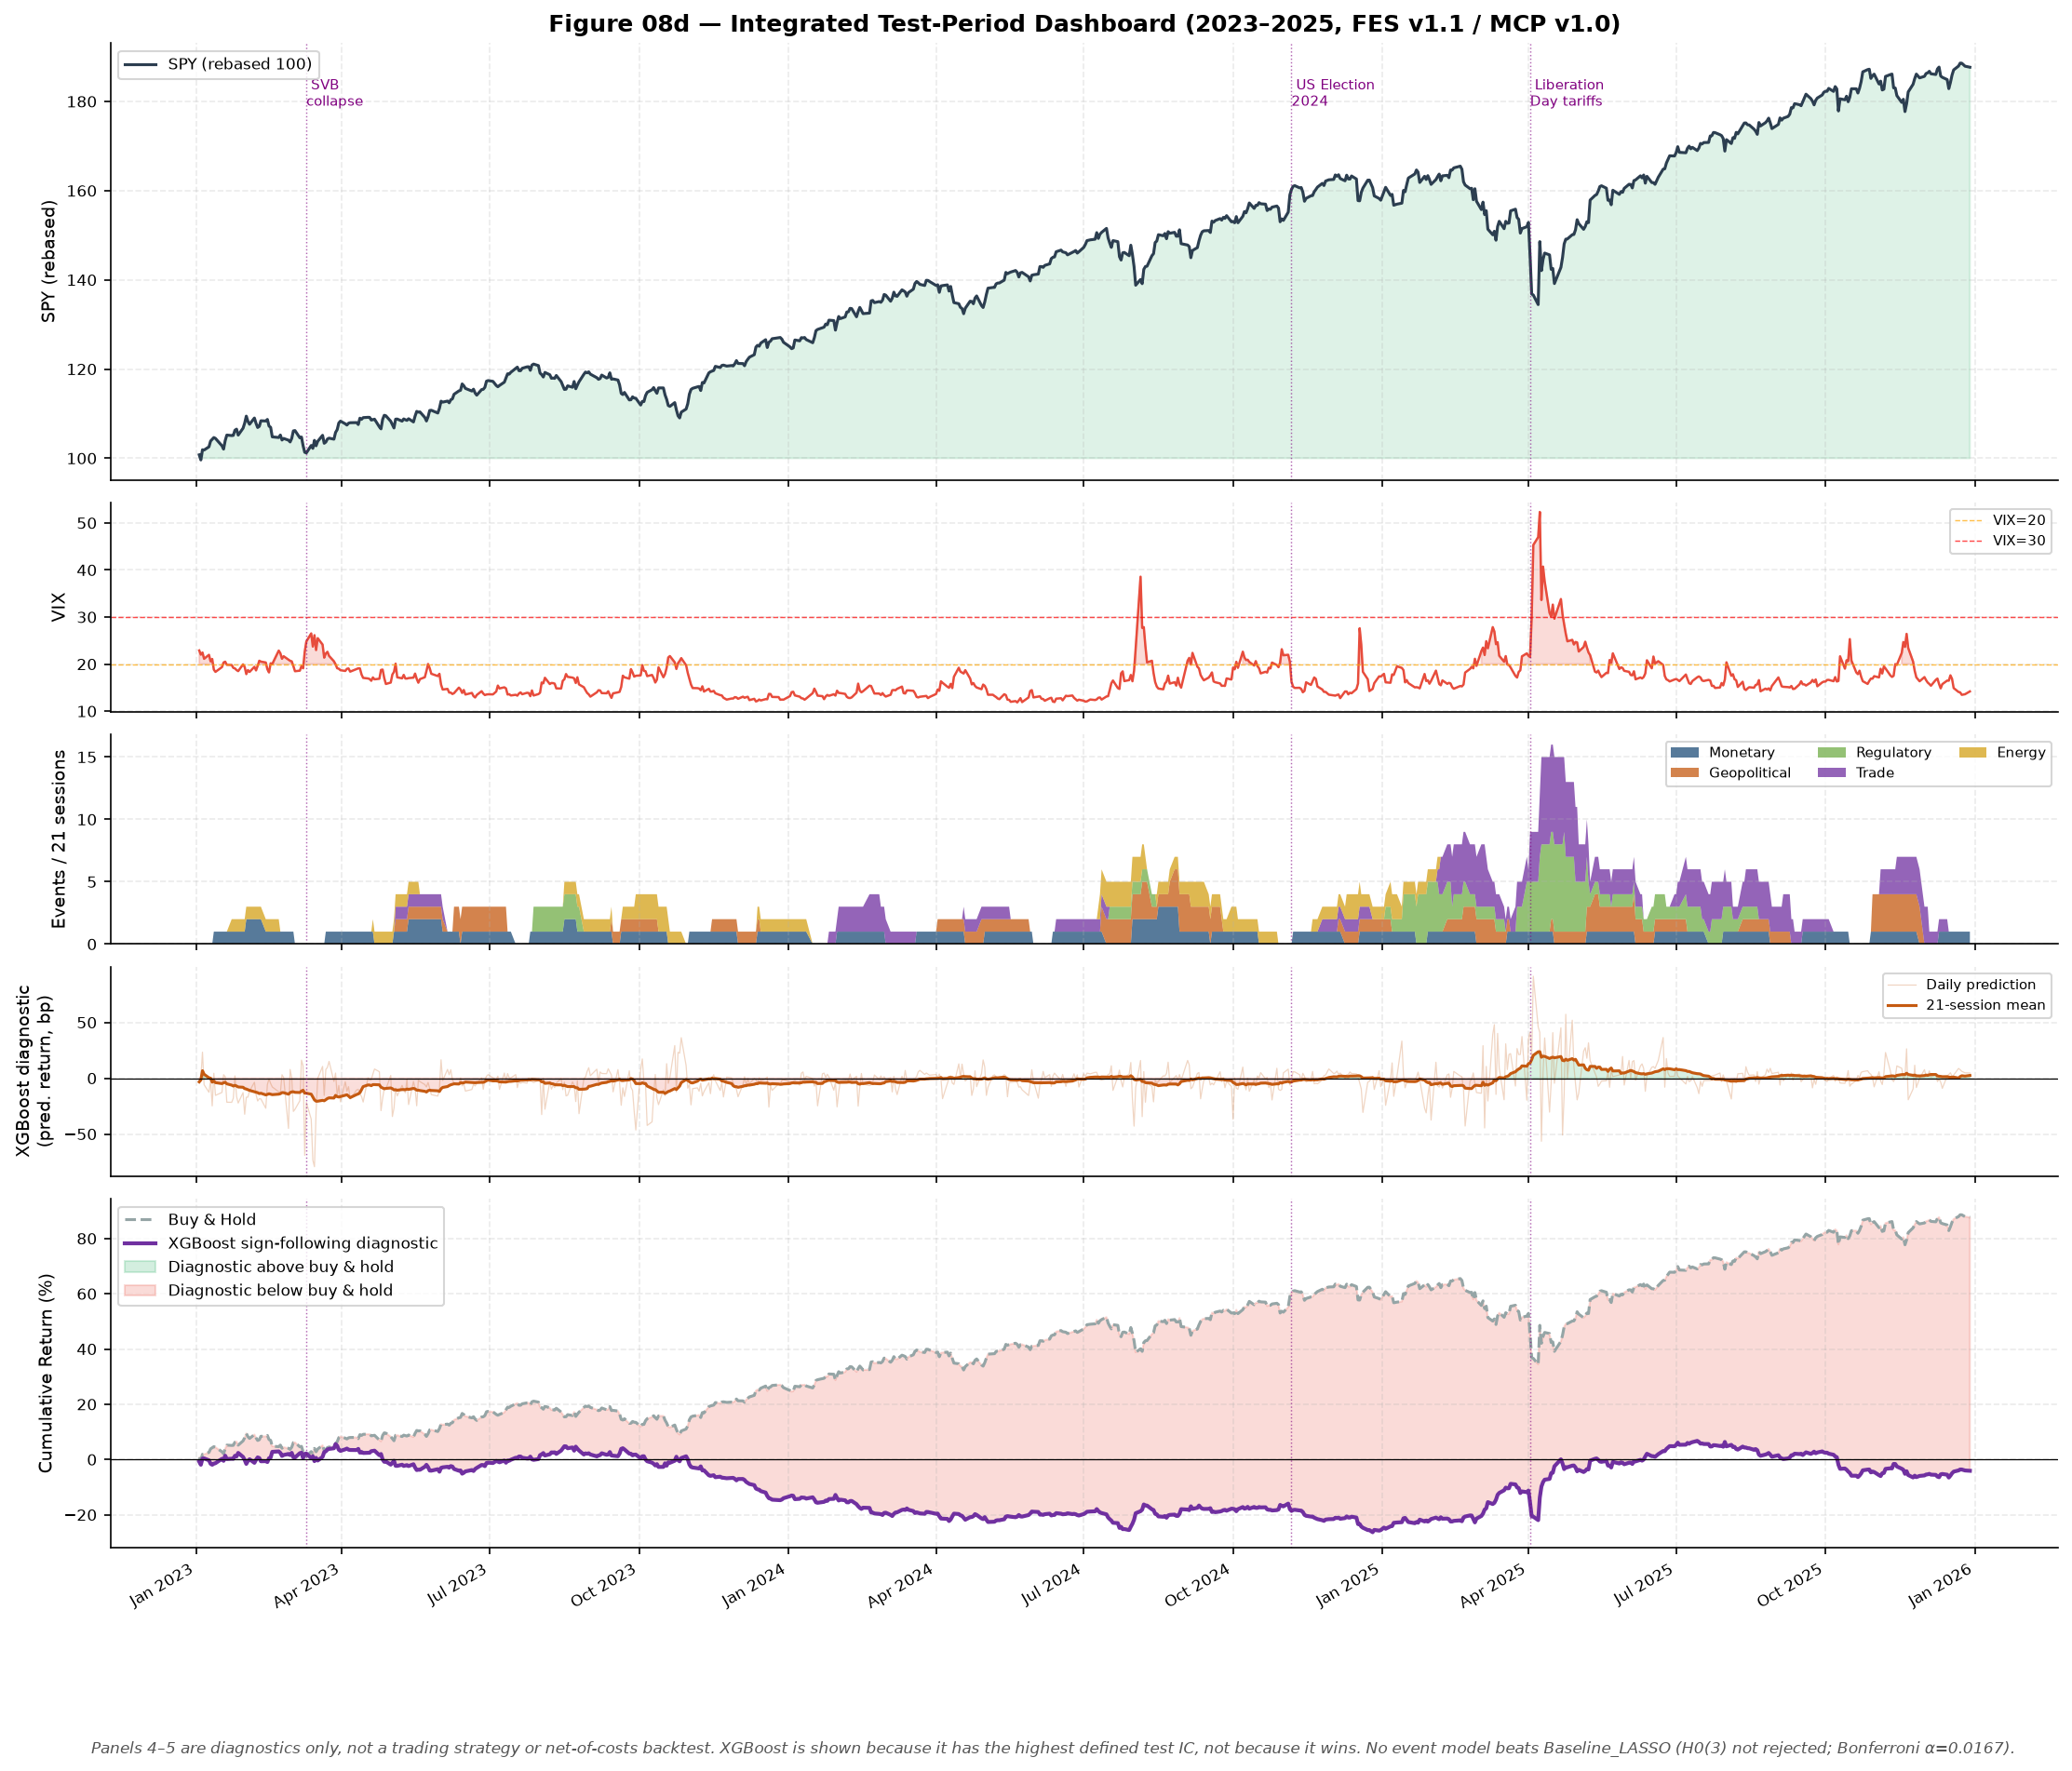

✓ Saved 08d_full_dashboard.png (FES v1.1 / MCP v1.0; diagnostic only)


In [6]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(5, 1, figure=fig, hspace=0.08, height_ratios=[2.5, 1.2, 1.2, 1.2, 2])

test_dates   = rep_dates
test_feat_df = feat_df[feat_df['date'] > TRAIN_CUT].copy().reset_index(drop=True)

# ── Panel 1: SPY price (reconstructed from actual next-day returns) ──────────
ax1 = fig.add_subplot(gs[0])
spy_price_idx = np.exp(np.cumsum(y_true)) * 100
ax1.plot(test_dates, spy_price_idx, color=C['spy'], linewidth=1.5, label='SPY (rebased 100)')
ax1.fill_between(test_dates, spy_price_idx, 100, where=spy_price_idx >= 100, alpha=0.15, color=C['positive'])
ax1.fill_between(test_dates, spy_price_idx, 100, where=spy_price_idx < 100, alpha=0.15, color=C['negative'])
ax1.set_ylabel('SPY (rebased)', fontsize=9)
ax1.legend(loc='upper left', fontsize=8)
ax1.set_xticklabels([])
ax1.set_title('Figure 08d — Integrated Test-Period Dashboard (2023–2025, FES v1.1 / MCP v1.0)', fontsize=12, fontweight='bold')

# ── Panel 2: VIX ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1], sharex=ax1)
vix_ser = test_feat_df.set_index('date')['vix'].reindex(pd.to_datetime(test_dates), method='ffill')
ax2.plot(test_dates, vix_ser.values, color=C['vix'], linewidth=1.2)
ax2.axhline(20, color='orange', linewidth=0.7, linestyle='--', alpha=0.7, label='VIX=20')
ax2.axhline(30, color='red', linewidth=0.7, linestyle='--', alpha=0.7, label='VIX=30')
ax2.fill_between(test_dates, vix_ser.values, 20, where=vix_ser.values > 20, alpha=0.2, color=C['vix'])
ax2.set_ylabel('VIX', fontsize=9)
ax2.legend(loc='upper right', fontsize=7)
ax2.set_xticklabels([])

# ── Panel 3: Daily event volume (stacked by type) ────────────────────────────
ax3 = fig.add_subplot(gs[2], sharex=ax1)
test_events = events_df[
    (events_df['date'] > pd.Timestamp(TRAIN_CUT)) &
    (events_df['event_type'].isin(EVENT_ORDER))
].copy()
daily_evt = (
    test_events.groupby(['date','event_type'])
    .size().unstack(fill_value=0)
    .reindex(columns=EVENT_ORDER, fill_value=0)
)
daily_evt = daily_evt.reindex(pd.to_datetime(test_dates), fill_value=0)
# A 21-session rolling count remains legible across the three-year canvas;
# one-pixel daily bars disappear at dissertation/page scale.
rolling_evt = daily_evt.rolling(21, min_periods=1).sum()
ax3.stackplot(test_dates,
              *[rolling_evt[et].values for et in EVENT_ORDER],
              colors=[C[et] for et in EVENT_ORDER],
              labels=[et.capitalize() for et in EVENT_ORDER], alpha=0.75)
ax3.set_ylabel('Events / 21 sessions', fontsize=9)
ax3.legend(loc='upper right', fontsize=7, ncol=3)
ax3.set_xticklabels([])

# ── Panel 4: Non-constant diagnostic model's predicted return ───────────────
ax4 = fig.add_subplot(gs[3], sharex=ax1)
signal_bp = y_rep * 10_000
signal_roll = pd.Series(signal_bp).rolling(21, min_periods=1).mean().values
ax4.plot(test_dates, signal_bp, color=MODEL_COLOURS[REPRESENTATIVE_MODEL],
         alpha=0.25, linewidth=0.6, label='Daily prediction')
ax4.plot(test_dates, signal_roll, color=MODEL_COLOURS[REPRESENTATIVE_MODEL],
         linewidth=1.5, label='21-session mean')
ax4.fill_between(test_dates, signal_roll, 0, where=signal_roll >= 0,
                 color=C['positive'], alpha=0.18)
ax4.fill_between(test_dates, signal_roll, 0, where=signal_roll < 0,
                 color=C['negative'], alpha=0.18)
ax4.axhline(0, color='black', linewidth=0.6)
ax4.set_ylabel(f'{REPRESENTATIVE_MODEL} diagnostic\n(pred. return, bp)', fontsize=9)
ax4.legend(loc='upper right', fontsize=7)
ax4.set_xticklabels([])

# ── Panel 5: Cumulative signal-based return vs buy-and-hold (illustrative) ──
ax5 = fig.add_subplot(gs[4], sharex=ax1)
strategy_daily = np.sign(y_rep) * y_true
cum_strat = (np.exp(np.cumsum(strategy_daily)) - 1) * 100
cum_bh    = (np.exp(np.cumsum(y_true)) - 1) * 100

ax5.plot(test_dates, cum_bh,    color=C['bh'],       linewidth=1.5,
         linestyle='--', label='Buy & Hold')
ax5.plot(test_dates, cum_strat, color=C['strategy'],  linewidth=2,
         label=f'{REPRESENTATIVE_MODEL} sign-following diagnostic')
ax5.fill_between(test_dates, cum_strat, cum_bh,
                 where=cum_strat >= cum_bh, alpha=0.2, color=C['positive'],
                 label='Diagnostic above buy & hold')
ax5.fill_between(test_dates, cum_strat, cum_bh,
                 where=cum_strat < cum_bh, alpha=0.2, color=C['negative'],
                 label='Diagnostic below buy & hold')
ax5.axhline(0, color='black', linewidth=0.6)
ax5.set_ylabel('Cumulative Return (%)', fontsize=9)
ax5.legend(loc='upper left', fontsize=8)

ax5.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
for upper_ax in [ax1, ax2, ax3, ax4]:
    upper_ax.tick_params(axis='x', which='both', labelbottom=False)

key_events = [
    (pd.Timestamp('2023-03-10'), 'SVB\ncollapse', ax1),
    (pd.Timestamp('2024-11-06'), 'US Election\n2024', ax1),
    (pd.Timestamp('2025-04-02'), 'Liberation\nDay tariffs', ax1),
]
test_min, test_max = pd.Timestamp(test_dates.min()), pd.Timestamp(test_dates.max())
for ts, label, ax in key_events:
    if test_min <= ts <= test_max:
        for a in [ax1, ax2, ax3, ax4, ax5]:
            a.axvline(ts, color='purple', linewidth=0.7, linestyle=':', alpha=0.6)
        ax1.text(ts, ax1.get_ylim()[1] * 0.96, f' {label}',
                 fontsize=7, color='purple', va='top')

fig.text(0.5, 0.005,
         f"Panels 4–5 are diagnostics only, not a trading strategy or net-of-costs backtest. "
         f"{REPRESENTATIVE_MODEL} is shown because it has the highest defined test IC, not because it wins. "
         f"No event model beats Baseline_LASSO (H0(3) not rejected; Bonferroni \u03b1=0.0167).",
         ha='center', fontsize=8, style='italic', color='#555555')
plt.savefig(FIGS / '08d_full_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08d_full_dashboard.png (FES v1.1 / MCP v1.0; diagnostic only)')

---
## Section 5 — Summary & Figure Index

In [7]:
print('=' * 65)
print('PHASE 8 — RESULTS VISUALISATION: COMPLETE')
print('=' * 65)

print('\nPUBLICATION FIGURES (300 dpi) → reports/figures/')
figures = [
    ('08a_event_landscape.png',    'Event Landscape',     'Event volume, type mix, sentiment & president breakdown'),
    ('08b_causal_evidence.png',    'Causal Evidence',     'CAR violin, DoWhy CI, sentiment scatter, VIX regime'),
    ('08c_predictive_pipeline.png','Predictive Pipeline', 'Feature groups, top features, SHAP, model comparison'),
    ('08d_full_dashboard.png',     'Full Dashboard',      'SPY + VIX + events + diagnostic signal (2023–2025)'),
]
for fname, title, desc in figures:
    path = FIGS / fname
    size = f'{path.stat().st_size / 1024:.0f} KB' if path.exists() else 'MISSING'
    print(f'  {fname:<38} [{size:>8}]  {desc}')

print('\nCOMPLETE FIGURE INVENTORY (all phases):')
all_figs = sorted(FIGS.glob('0*.png'))
for p in all_figs:
    print(f'  {p.name}')

print(f'\nPROJECT STATUS:')
phases = [
    ('01', 'Data Collection',      '✅'),
    ('02', 'EDA',                  '✅'),
    ('03', 'Event Detection',      '✅'),
    ('04', 'Causal Analysis',      '✅'),
    ('05', 'Feature Engineering',  '✅'),
    ('06', 'Model Training',       '✅'),
    ('07', 'Model Evaluation',     '✅'),
    ('08', 'Results Visualisation','✅'),
]
for num, name, status in phases:
    print(f'  Phase {num}: {name:<25} {status}')


PHASE 8 — RESULTS VISUALISATION: COMPLETE

PUBLICATION FIGURES (300 dpi) → reports/figures/
  08a_event_landscape.png                [  591 KB]  Event volume, type mix, sentiment & president breakdown
  08b_causal_evidence.png                [  513 KB]  CAR violin, DoWhy CI, sentiment scatter, VIX regime
  08c_predictive_pipeline.png            [  672 KB]  Feature groups, top features, SHAP, model comparison
  08d_full_dashboard.png                 [ 1034 KB]  SPY + VIX + events + diagnostic signal (2023–2025)

COMPLETE FIGURE INVENTORY (all phases):
  01_spy_rebased_price.png
  02b_return_distribution.png
  02c_vix_and_macro.png
  02g_app_doc_distribution.png
  02i_docs_vs_returns.png
  02j_fomc_distribution.png
  02m_descriptive_distributions.png
  02n_qq_plots.png
  02p_rolling_stationarity.png
  02q_acf_pacf.png
  02r_correlation_heatmap.png
  03a_sentiment_distribution.png
  03b_sentiment_timeline.png
  03c_high_impact_events.png
  03d_sentiment_by_event_type.png
  04a_car_by_even

## Handoff Note — End of Pipeline

This is the final notebook in the pipeline (`Dissertation` follows). All four figures (`08a`–`08d`) are current FES v1.1 outputs sourced exclusively from validation-passing upstream artefacts. `08c` states the RQ2 and RQ3 null findings directly; `08d` labels XGBoost as a non-constant diagnostic view rather than a winner or trading strategy. The final cell persists figure dimensions, SHA-256 hashes, input bindings, and validation `PASS` in `reports/figures/results_visualisation_validation.json`.

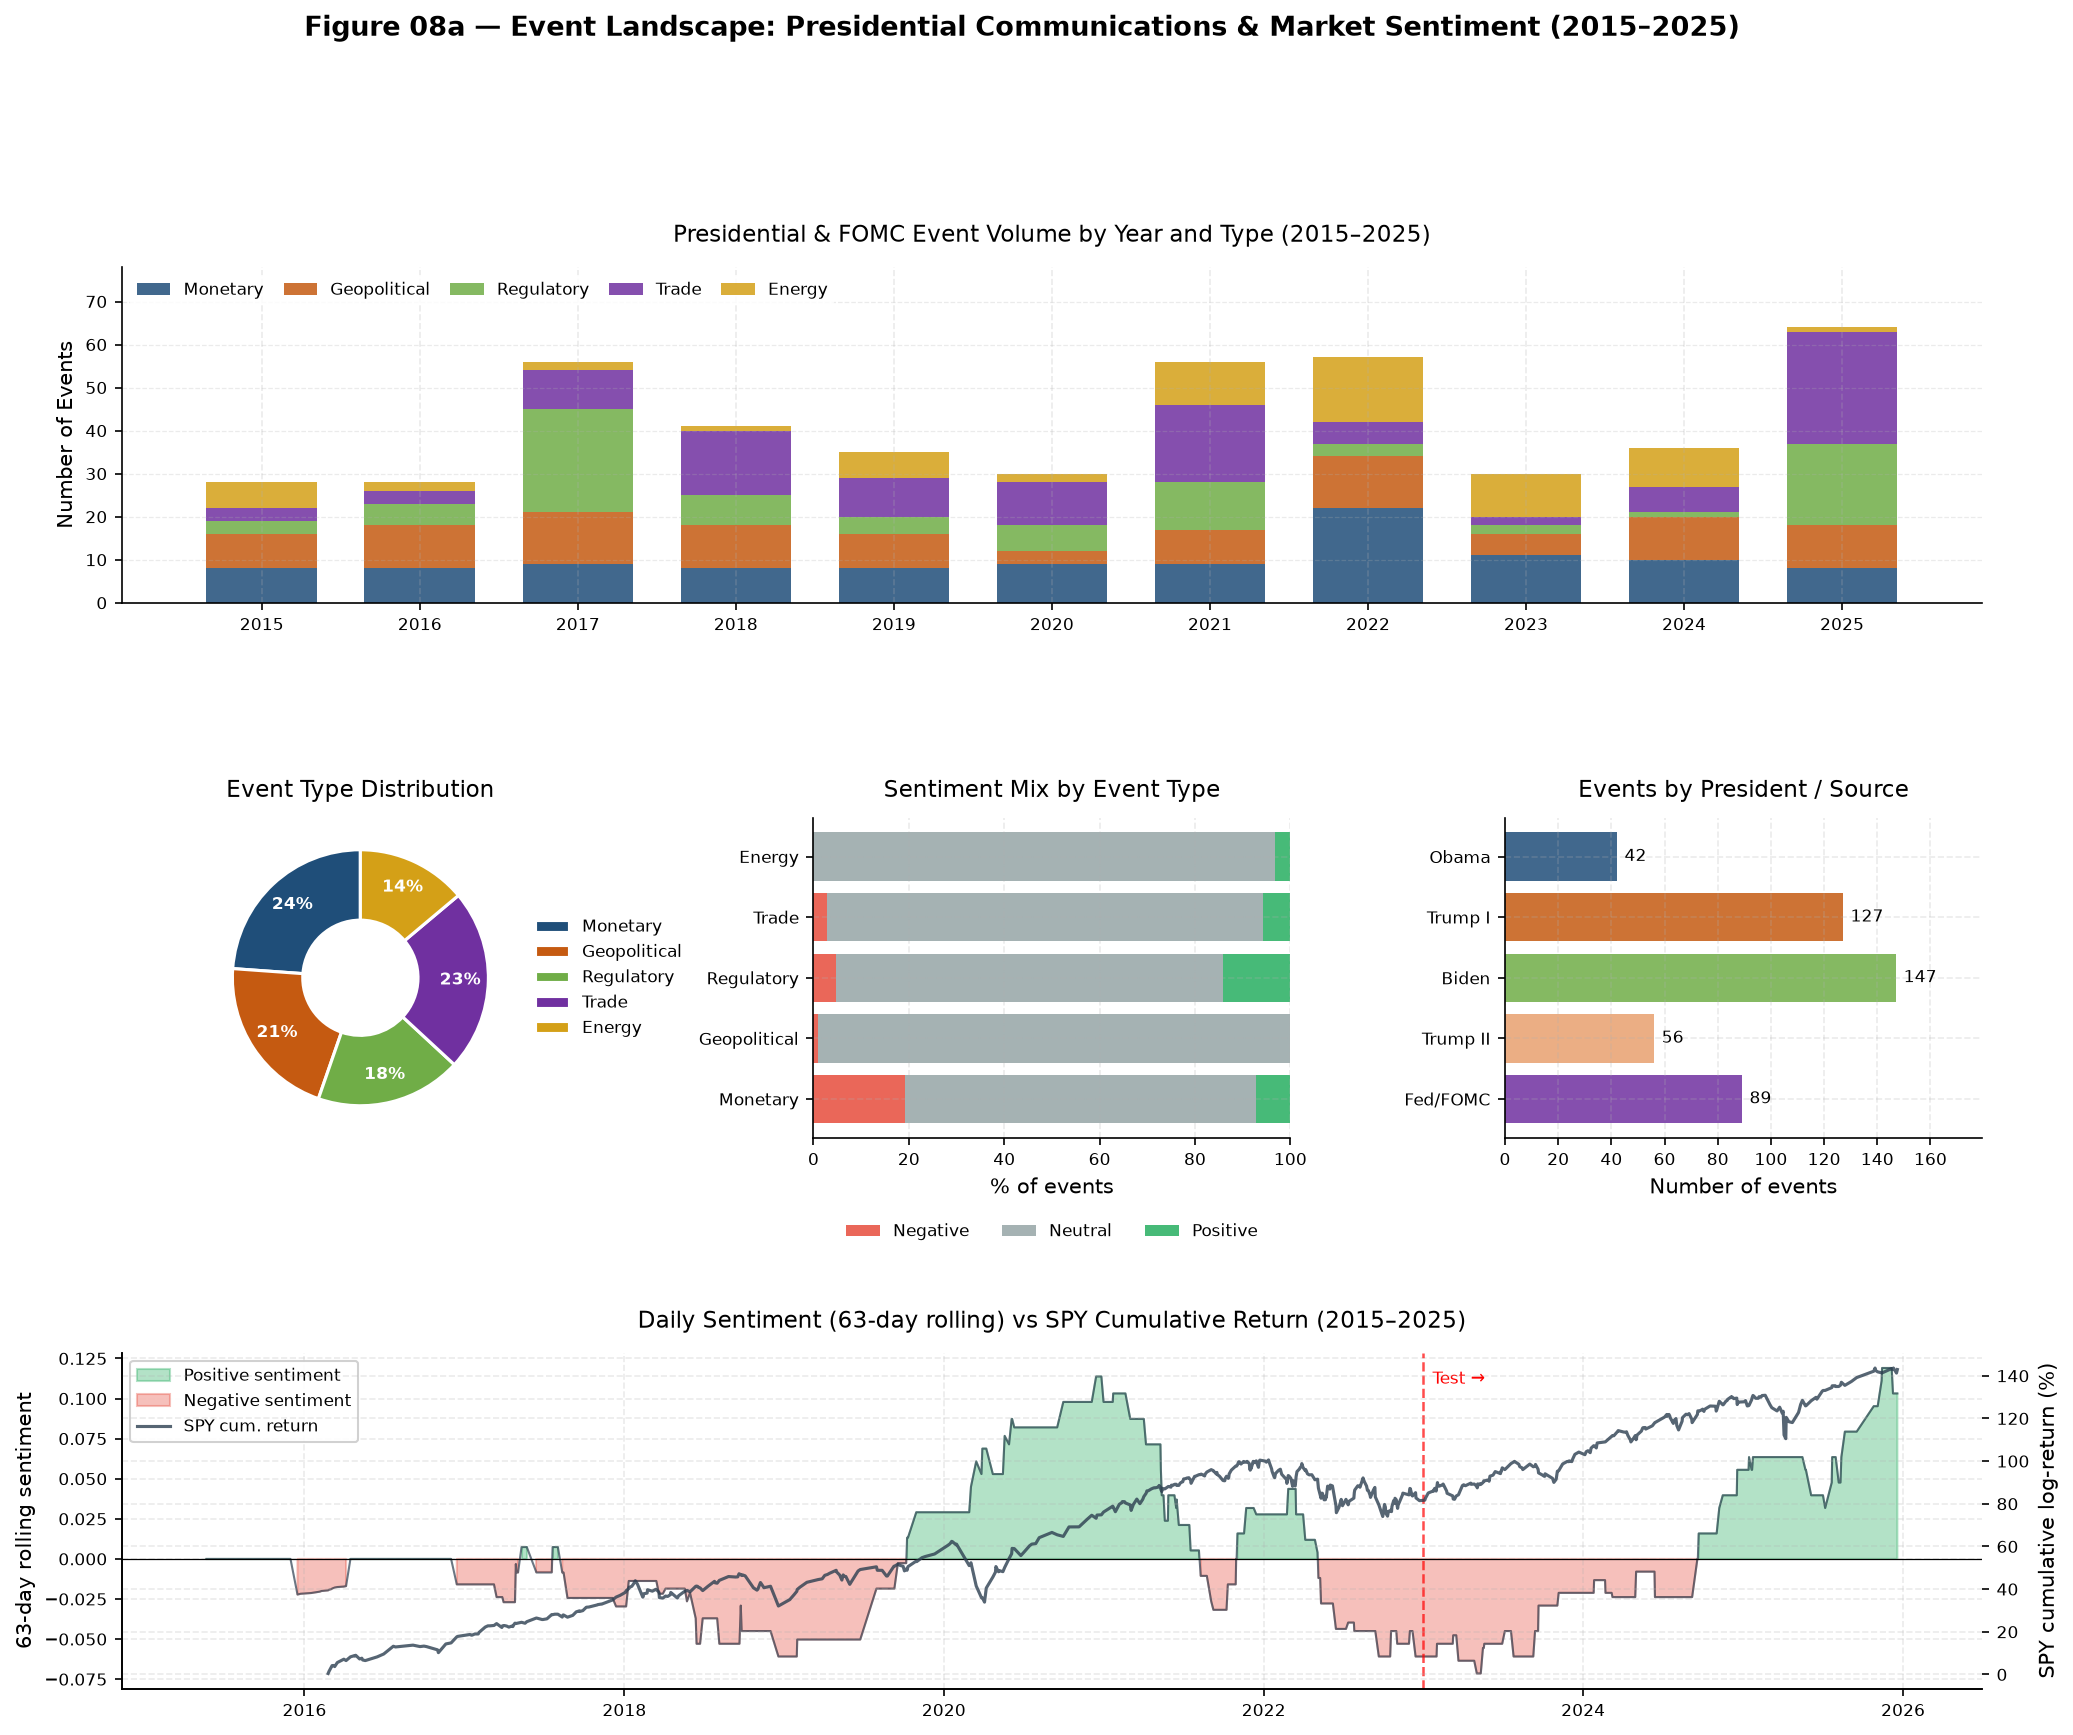

✓ Saved 08a_event_landscape.png


✓ Visualisation validation PASS: results_visualisation_validation.json


In [8]:
"""
Figure 08a — Event Landscape (revised layout)
Drop-in replacement for the original plotting block.
All upstream variables are assumed already defined in your session:
    events_df, sent_df, feat_df, C, EVENT_ORDER, TRAIN_CUT, FIGS
"""

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(
    3, 3, figure=fig,
    hspace=0.65, wspace=0.45,
    height_ratios=[1.05, 1, 1.05],
)

# ── Panel 1 (top, full width): Event volume over time by type ─────────────────
ax1 = fig.add_subplot(gs[0, :])
yearly = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .assign(year=events_df['date'].dt.year)
    .groupby(['year', 'event_type'])
    .size().unstack(fill_value=0)
)
yearly = yearly.reindex(columns=[e for e in EVENT_ORDER if e in yearly.columns])
bottom = np.zeros(len(yearly))
for col in yearly.columns:
    ax1.bar(yearly.index, yearly[col], bottom=bottom,
            color=C[col], alpha=0.85, label=col.capitalize(), width=0.7)
    bottom += yearly[col].values
ax1.set_ylabel('Number of Events')
ax1.set_title('Presidential & FOMC Event Volume by Year and Type (2015\u20132025)', pad=12)
# FIX: legend kept inside the axes (not above it), so it never competes with
# the title for vertical space. Extra headroom via margins(y=0.22) plus a
# semi-opaque background keeps it legible against the tallest bars (2021, 2024).
ax1.margins(y=0.22)
ax1.legend(loc='upper left', ncol=5, fontsize=8,
           frameon=True, framealpha=0.85, edgecolor='none', columnspacing=1.2)
ax1.set_xticks(yearly.index)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.25, linewidth=0.6)

# ── Panel 2 (mid-left): Event type distribution (donut) ──────────────────────
ax2 = fig.add_subplot(gs[1, 0])
type_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['event_type'].value_counts().reindex(EVENT_ORDER).fillna(0)
)
# FIX: drop inline category labels (they collided on small wedges) and use a
# side legend instead; keep percentage labels inside the wedges only.
wedges, _, autotexts = ax2.pie(
    type_counts.values,
    labels=None,
    colors=[C[t] for t in type_counts.index],
    autopct=lambda p: f'{p:.0f}%' if p >= 4 else '',   # suppress label clutter on tiny wedges
    startangle=90,
    pctdistance=0.78, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color('white')
    at.set_fontweight('bold')
ax2.set_title('Event Type Distribution', pad=10)
ax2.legend(wedges, [t.capitalize() for t in type_counts.index],
           loc='center left', bbox_to_anchor=(1.0, 0.5),
           fontsize=8, frameon=False)

# ── Panel 3 (mid-centre): Sentiment distribution by event type ───────────────
ax3 = fig.add_subplot(gs[1, 1])
sent_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .groupby(['event_type', 'sentiment_label'])
    .size().unstack(fill_value=0)
)
sent_counts = sent_counts.reindex(index=EVENT_ORDER)
sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0) * 100
bottom_s = np.zeros(len(sent_pct))
for sent_label, col in [('negative', C['negative']), ('neutral', C['neutral']), ('positive', C['positive'])]:
    if sent_label in sent_pct.columns:
        ax3.barh([e.capitalize() for e in sent_pct.index],
                 sent_pct[sent_label], left=bottom_s,
                 color=col, alpha=0.85, label=sent_label.capitalize())
        bottom_s += sent_pct[sent_label].values
ax3.set_xlabel('% of events')
ax3.set_title('Sentiment Mix by Event Type', pad=10)
# FIX: legend relocated below the axis, horizontal, so it never overlaps the bars
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
           ncol=3, fontsize=8, frameon=False)
ax3.set_xlim(0, 100)
ax3.spines[['top', 'right']].set_visible(False)

# ── Panel 4 (mid-right): Events by president ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
pres_short = {
    'Barack Obama': 'Obama',
    'Donald J. Trump (1st Term)': 'Trump I',
    'Joseph R. Biden, Jr.': 'Biden',
    'Donald J. Trump (2nd Term)': 'Trump II',
    'Federal Reserve': 'Fed/FOMC',
}
pres_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['president'].map(pres_short).value_counts()
)
pres_order = ['Obama', 'Trump I', 'Biden', 'Trump II', 'Fed/FOMC']
pres_counts = pres_counts.reindex([p for p in pres_order if p in pres_counts.index])
# FIX: Trump I / Trump II now get distinguishable shades instead of an identical orange
PALETTE_PRES = {
    'Obama': '#1f4e79',
    'Trump I': '#c55a11',
    'Biden': '#70ad47',
    'Trump II': '#e8a06e',
    'Fed/FOMC': '#7030a0',
}
colors = [PALETTE_PRES[p] for p in pres_counts.index][::-1]
ax4.barh(pres_counts.index[::-1], pres_counts.values[::-1],
         color=colors, alpha=0.85)
# FIX: extend xlim so value labels never crowd/clip the right edge
ax4.set_xlim(0, pres_counts.values.max() * 1.22)
for i, val in enumerate(pres_counts.values[::-1]):
    ax4.text(val + pres_counts.values.max() * 0.02, i, f'{val:,}',
             va='center', fontsize=8)
ax4.set_xlabel('Number of events')
ax4.set_title('Events by President / Source', pad=10)
ax4.spines[['top', 'right']].set_visible(False)

# ── Panel 5 (bottom, full width): Rolling daily sentiment vs SPY ─────────────
ax5 = fig.add_subplot(gs[2, :])
# FIX: dropna instead of fillna(0) — zero-filling missing days created a false
# trough at the start of the series before rolling was applied
daily_overall = sent_df.set_index('date')['overall_mean_sentiment'].dropna()
rolling_sent = daily_overall.rolling(63, min_periods=20).mean()

spy_ret = feat_df.set_index('date')['log_return']
spy_cum = (spy_ret.cumsum() * 100).reindex(rolling_sent.index, method='ffill')

ax5b = ax5.twinx()
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent >= 0, alpha=0.35, color=C['positive'], label='Positive sentiment')
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent < 0, alpha=0.35, color=C['negative'], label='Negative sentiment')
ax5.plot(rolling_sent.index, rolling_sent, linewidth=1, color='#2c3e50', alpha=0.7)
ax5b.plot(spy_cum.index, spy_cum.values, color=C['spy'], linewidth=1.5, alpha=0.8, label='SPY cum. return')
ax5.set_ylabel('63-day rolling sentiment')
ax5b.set_ylabel('SPY cumulative log-return (%)')
ax5.set_title('Daily Sentiment (63-day rolling) vs SPY Cumulative Return (2015\u20132025)', pad=12)
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
# FIX: legend given a solid backing so it stays legible over the shaded fill
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           fontsize=8, framealpha=0.9)
ax5.axhline(0, color='black', linewidth=0.6)
ax5.axvline(pd.Timestamp(TRAIN_CUT), color='red', linewidth=1.2,
            linestyle='--', alpha=0.7)
ax5.text(pd.Timestamp(TRAIN_CUT), ax5.get_ylim()[1] * 0.85, '  Test \u2192',
         color='red', fontsize=8)
ax5.spines[['top', 'right']].set_visible(False)

# FIX: suptitle pushed further above panel 1, and top margin reserved explicitly
# so the figure-level title never crowds the first subplot title
plt.suptitle('Figure 08a \u2014 Event Landscape: Presidential Communications & Market Sentiment (2015\u20132025)',
             fontsize=13, fontweight='bold', y=1.04)
plt.subplots_adjust(top=0.90)
plt.savefig(FIGS / '08a_event_landscape.png', dpi=300, bbox_inches='tight')
plt.show()
print('\u2713 Saved 08a_event_landscape.png')

# ── Final figure validation and provenance binding ───────────────────────────
figure_paths = [FIGS / f'08{letter}_{name}.png' for letter, name in [
    ('a', 'event_landscape'), ('b', 'causal_evidence'),
    ('c', 'predictive_pipeline'), ('d', 'full_dashboard')]]
assert all(p.exists() and p.stat().st_size > 0 for p in figure_paths)
figure_dimensions_px = {}
for path in figure_paths:
    image = plt.imread(path)
    figure_dimensions_px[path.name] = [int(image.shape[1]), int(image.shape[0])]

visualisation_validation = {
    'validation_status': 'PASS',
    'visualisation_version': '1.2',
    'feature_matrix_version': 'FES v1.1',
    'feature_matrix_sha256': matrix_hash,
    'model_evaluation_validation_status': model_eval_validation['validation_status'],
    'rq1_event_study_min_p': min(rq1_event_type_p.values()),
    'rq1_event_study_min_bh_q': float(rq1_stats['p_value_bh'].min()),
    'rq1_event_study_bh_rejections': int(rq1_stats['reject_bh_0_05'].sum()),
    'rq1_event_study_max_abs_cohens_d': float(rq1_stats['cohens_d'].abs().max()),
    'rq1_overall_dowhy': rq1_overall_dowhy,
    'rq2_verdict': rq2_verdict,
    'rq3_verdict': rq3_verdict,
    'diagnostic_model': REPRESENTATIVE_MODEL,
    'diagnostic_model_selection': 'Highest defined test IC among non-constant event candidates; not a winner',
    'input_sha256': {
        'notebook_04_causal_analysis': sha256(ROOT / 'notebooks' / '04_causal_analysis.ipynb'),
        'rq1_reporting_validation': sha256(PROC / 'rq1_reporting_validation.json'),
        'event_type_statistics': sha256(PROC / 'event_type_statistics.parquet'),
        'feature_matrix_validation': sha256(PROC / 'feature_matrix_validation.json'),
        'baseline_model_validation': sha256(BASE / 'baseline_model_validation.json'),
        'model_evaluation_validation': sha256(MC / 'model_evaluation_validation.json'),
        'statistical_tests': sha256(MC / 'statistical_tests.json'),
        'feature_importance': sha256(MC / 'feature_importance.parquet'),
        'event_model_predictions': sha256(MC / 'event_model_predictions.parquet'),
        'causal_overall_estimate': sha256(PROC / 'causal_overall_estimate.json'),
    },
    'figure_dimensions_px': figure_dimensions_px,
    'figure_sha256': {p.name: sha256(p) for p in figure_paths},
}
validation_path = FIGS / 'results_visualisation_validation.json'
with open(validation_path, 'w') as fh:
    json.dump(visualisation_validation, fh, indent=2, allow_nan=False)
with open(validation_path) as fh:
    reloaded_validation = json.load(fh)
assert reloaded_validation['validation_status'] == 'PASS'
assert all(sha256(FIGS / name) == digest
           for name, digest in reloaded_validation['figure_sha256'].items())
print(f'\u2713 Visualisation validation PASS: {validation_path.name}')